In [1]:
import pandas as pd, numpy as np

%load_ext autoreload
%autoreload 2

!date

Tue Jul 30 12:55:27 PDT 2024


# HCES Data Extraction
We have HCES data to inform rice consumption (of PSD-distributed and non-PSD rice) by women and birthing people of 
reproductive age (WBPRA) and U5 children in India. We need to do further investigation as to what percentage of PSD-
distributed rice has been fortified with iron and folate.

HCES data and documentation is saved on Sharepoint here: https://uwnetid.sharepoint.com/:f:/r/sites/ihme_simulation_science_team/Shared%20Documents/Research/LSFF/07_Data/HCES_22_data_files?csf=1&web=1&e=wmxQSD

Item codes for 'Rice' include: 101, 102, and 061. See Section 5.1 of the above documentation for more context.
- Item code 101 signifies rice procured through PDS, using ration card.
- Item code 061 signifies rice procured through PDS, free of charge.
- Item code 102 signifies rice procured/consumed from other sources. (NOTE: Presumably this is unfortified rice.)

We also will need to approximate DHS wealth quintiles in the HCES data, by using similar variables as is used by the DHS to 
calculate wealth quintiles in India (see DHS wealth quintile documentation here: 
https://dhsprogram.com/programming/wealth%20index/India%20DHS%202015-16/India%202015-16%20sps.txt)

In this notebook, we extract the raw data from the HCES website and do some initial processing in order to create files 
that we can further tabulate based on our project needs in a later step. For now, we process these raw data into dataframes 
that have a row for each household/individual with the following columns:
- Whether or not rice was consumed (binary variable - this will be used to calculate coverage percentages later)
- Amount of PDS rice consumed (grams per day - currently in raw HCES, *I think* this is in kg per 2 weeks; this will be used to calculate fortified rice consumption amount) 
- Amount of non-PDS rice consumed (grams per day - currently in raw HCES, *I think* this is in kg per 2 weeks; this will be used to calculate unfortified rice consumption amount) 
- Wealth composite score/quintile 
- Sex/gender (will be used to calculate WBPRA)
- Age (will be used to tabulate age groups)

## Load data

In [2]:
data_dir = '/snfs1/DATA/Incoming Data/IND/HOUSEHOLD_CONSUMPTION_EXPENDITURE_SURVEY_HCES/2022_2023'

In [3]:
level_1_widths = [4, 4, 5, 1, 2, 3, 2, 2, 2, 2, 1, 4, 2, 1, 1, 2, 1, 2, 1, 1, 15]

level_1 = pd.read_fwf(
    f'{data_dir}/hces22_lvl_01.TXT',
    header=None,
    widths=level_1_widths,
    names=[
        "survey_name",
        "year",
        "fsu_serial_no",
        "sector",
        "state",
        "nss_region",
        "district",
        "stratum",
        "sub_stratum",
        "panel",
        "sub_sample",
        "fod_sub_region",
        "sample_su_no",
        "sample_sub_division_no",
        "second_stage_stratum_no",
        "sample_household_no",
        "questionnaire_no",
        "level",
        "survey_code",
        "reason_for_substitution_code",
        "multiplier"
    ],
)
level_1

,survey_name,year,fsu_serial_no,sector,state,nss_region,district,stratum,sub_stratum,panel,...,fod_sub_region,sample_su_no,sample_sub_division_no,second_stage_stratum_no,sample_household_no,questionnaire_no,level,survey_code,reason_for_substitution_code,multiplier
0,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,2,1,H,1,1,NaN,35560.0
1,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,3,1,H,1,1,NaN,30331.0
2,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,3,2,H,1,1,NaN,30331.0
3,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,3,3,H,1,1,NaN,30331.0
4,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,3,4,H,1,1,NaN,30331.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES,2022,39510,2,28,283,13,22,2,10,...,2810,1.0,NaN,3,14,H,1,1,NaN,73515.0
261742,HCES,2022,39510,2,28,283,13,22,2,10,...,2810,1.0,NaN,3,15,H,1,1,NaN,73515.0
261743,HCES,2022,39510,2,28,283,13,22,2,10,...,2810,1.0,NaN,3,16,H,1,1,NaN,73515.0
261744,HCES,2022,39510,2,28,283,13,22,2,10,...,2810,1.0,NaN,3,17,H,1,1,NaN,73515.0


In [4]:
level_1.sub_sample

0         1
1         1
2         1
3         1
4         1
         ..
261741    2
261742    2
261743    2
261744    2
261745    2
Name: sub_sample, Length: 261746, dtype: int64

In [5]:
level_1.fod_sub_region

0          120
1          120
2          120
3          120
4          120
          ... 
261741    2810
261742    2810
261743    2810
261744    2810
261745    2810
Name: fod_sub_region, Length: 261746, dtype: int64

In [6]:
common_id_columns = level_1.columns[:16]
common_id_column_widths = level_1_widths[:16]

level_1["common_id"] = ""

for col, width in zip(common_id_columns, common_id_column_widths):
    fill_val = '0'
    side = 'left'
    if col in ('sample_su_no', 'sample_sub_division_no', 'panel'):
        # No clue.
        fill_val = ' '
        side = 'right'

    values = level_1[col].fillna(fill_val).astype(str).str.replace('.0', '').str.pad(width, fillchar=fill_val, side=side)
    assert (values.str.len() == width).all()
    level_1["common_id"] += values

level_1["common_id"]

0         HCES2022655561010131113011 101202  201
1         HCES2022655561010131113011 101202  301
2         HCES2022655561010131113011 101202  302
3         HCES2022655561010131113011 101202  303
4         HCES2022655561010131113011 101202  304
                           ...                  
261741    HCES20223951022828313220210228101  314
261742    HCES20223951022828313220210228101  315
261743    HCES20223951022828313220210228101  316
261744    HCES20223951022828313220210228101  317
261745    HCES20223951022828313220210228101  318
Name: common_id, Length: 261746, dtype: object

In [7]:
level_3 = pd.read_fwf(
    '/snfs1/DATA/Incoming Data/IND/HOUSEHOLD_CONSUMPTION_EXPENDITURE_SURVEY_HCES/2022_2023/hces22_lvl_03.TXT',
    header=None,
    widths=[38,1,2,2,1,3,5,1,1,1,1,1,1,1,1,1,9,1,1,1,1,1,2,1,2,3,1,2,1,1,1,1,2,15],
    names=[
        "common_id",
        "questionnaire_no",
        "level",
        "hh_size",
        "household_member_economic_activity_last_365_days",
        "nco_2015_code",
        "nic_2008_code",
        "max_income_source_last_365_days",
        "major_income_source_self_employment_sector",
        "major_income_regular_wage_sector",
        "major_income_casual_labour_sector",
        "household_type",
        "head_religion",
        "head_social_group",
        "land_ownership",
        "land_type_owned",
        "total_owned_land_area",
        "has_dwelling",
        "dwelling_unit_type",
        "building_material_wall",
        "building_material_roof",
        "building_material_floor",
        "cooking_energy_source",
        "lighting_energy_source",
        "drinking_water_source",
        "water_fetching_time_minutes",
        "latrine_access_type",
        "latrine_type",
        "ration_card_type",
        "rural_rent_rate_availability",
        "pmgky_benefit_status",
        "household_child_mortality_last_5_years",
        "child_mortality_count_last_5_years",
        "multiplier",
    ],
)
level_3

,common_id,questionnaire_no,level,hh_size,household_member_economic_activity_last_365_days,nco_2015_code,nic_2008_code,max_income_source_last_365_days,major_income_source_self_employment_sector,major_income_regular_wage_sector,...,drinking_water_source,water_fetching_time_minutes,latrine_access_type,latrine_type,ration_card_type,rural_rent_rate_availability,pmgky_benefit_status,household_child_mortality_last_5_years,child_mortality_count_last_5_years,multiplier
0,HCES2022655561010131113011 101202 201,H,3,5,1,332.0,68200.0,1.0,2.0,NaN,...,2,0.0,1,2.0,3,2.0,2,2,0,35560.0
1,HCES2022655561010131113011 101202 301,H,3,6,1,931.0,42909.0,3.0,NaN,NaN,...,2,0.0,1,2.0,2,2.0,2,2,0,30331.0
2,HCES2022655561010131113011 101202 302,H,3,8,1,833.0,49211.0,1.0,2.0,NaN,...,2,0.0,1,2.0,3,2.0,2,2,0,30331.0
3,HCES2022655561010131113011 101202 303,H,3,4,1,142.0,47713.0,1.0,2.0,NaN,...,2,0.0,1,2.0,0,2.0,2,2,0,30331.0
4,HCES2022655561010131113011 101202 304,H,3,4,1,833.0,49211.0,1.0,2.0,NaN,...,2,0.0,1,2.0,3,2.0,2,2,0,30331.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES20223951022828313220210228101 314,H,3,2,1,832.0,49219.0,1.0,NaN,NaN,...,11,10.0,1,1.0,4,NaN,1,2,0,73515.0
261742,HCES20223951022828313220210228101 315,H,3,4,1,216.0,85500.0,2.0,NaN,NaN,...,2,0.0,1,1.0,0,NaN,1,2,0,73515.0
261743,HCES20223951022828313220210228101 316,H,3,3,1,411.0,84119.0,2.0,NaN,NaN,...,2,0.0,1,1.0,4,NaN,1,2,0,73515.0
261744,HCES20223951022828313220210228101 317,H,3,5,1,112.0,47711.0,1.0,NaN,NaN,...,2,0.0,1,1.0,4,NaN,1,2,0,73515.0


In [8]:
assert level_3.common_id.is_unique

In [9]:
level_3.cooking_energy_source

0         2
1         2
2         2
3         2
4         2
         ..
261741    2
261742    2
261743    2
261744    2
261745    2
Name: cooking_energy_source, Length: 261746, dtype: int64

In [10]:
binary_columns = ["land_ownership", "has_dwelling"]

for col in binary_columns:
    level_3[col] = level_3[col].map({
        1: 1.0,
        2: 0.0,
    }).astype(float)

In [11]:
level_3.loc[level_3.land_ownership == 0, "total_owned_land_area"] = 0

In [12]:
level_3["dwelling_unit_type"] = level_3.dwelling_unit_type.map({
    1: 'owned',
    2: 'hired',
    3: 'others',
})
level_3["house_ownership"] = (level_3.has_dwelling == 1) & (level_3.dwelling_unit_type == 'owned')

In [13]:
materials = {
    1: 'grass',
    2: 'mud',
    3: 'canvas',
    4: 'katcha',
    5: 'tiles',
    6: 'brick',
    7: 'metal',
    8: 'cement',
    9: 'pucca',
}

for col in ["building_material_wall", "building_material_roof", "building_material_floor"]:
    level_3[col] = level_3[col].map(materials)
    level_3.loc[level_3.has_dwelling == 0, col] = 'none'

In [14]:
level_3["cooking_energy_source"] = level_3.cooking_energy_source.map({
    1: 'firewood',
    2: 'liquid petroleum gas',
    3: 'other natural gas',
    4: 'dung',
    5: 'kerosene',
    6: 'coal',
    7: 'gobar',
    8: 'other biogas',
    10: 'charcoal',
    11: 'electricity',
    12: 'no cooking',
    9: 'other',
})

In [15]:
level_3["lighting_energy_source"] = level_3.lighting_energy_source.map({
    1: 'electricity',
    2: 'kerosene',
    3: 'other oil',
    4: 'gas',
    5: 'candle',
    6: 'no lighting',
    9: 'other',
})

In [16]:
level_3["drinking_water_source"] = level_3.drinking_water_source.map({
    1: 'bottled',
    2: 'piped into dwelling',
    3: 'piped to yard',
    4: 'piped from neighbor',
    5: 'public tap',
    6: 'tube well',
    7: 'hand pump',
    8: 'well: protected',
    9: 'well: unprotected',
    10: 'tanker-truck: public',
    11: 'tanker-truck: private',
    12: 'spring: protected',
    13: 'spring: unprotected',
    14: 'rainwater collection',
    15: 'tank or pond',
    16: 'other surface water',
    19: 'other',
})

In [17]:
level_3["latrine_access_type"] = level_3.latrine_access_type.map({
    1: 'exclusive',
    2: 'common',
    3: 'public, free',
    4: 'public, paid',
    5: 'no latrine',
    9: 'other',
})

In [18]:
level_3["latrine_type"] = level_3.latrine_type.map({
    1: 'flush to piped',
    2: 'flush to septic',
    3: 'flush to twin leach pit',
    4: 'flush to single leach pit',
    5: 'other flush',
    6: 'improved pit',
    7: 'pit with slab',
    8: 'pit without slab',
    10: 'composting',
    11: 'open',
    19: 'other',
})

In [19]:
level_3["latrine_access_and_type"] = np.where(
    level_3.latrine_access_type == 'no latrine',
    'no latrine',
    np.where(
        level_3.latrine_access_type.notnull() & level_3.latrine_type.notnull(),
        (level_3["latrine_access_type"] == 'exclusive').map({True: "", False: "shared "}) + level_3.latrine_type,
        np.nan
    ) 
)

<Axes: >

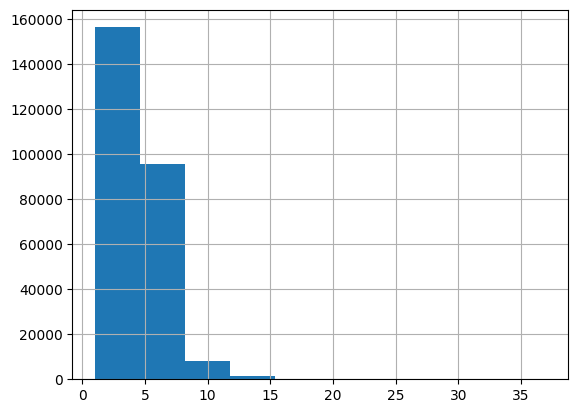

In [20]:
# The fact that there are a couple very large households (e.g. 20+ members) is a little 
# surprising - maybe we can investigate to confirm these are some kind of GQ. 
level_3.hh_size.hist()

In [21]:
level_7 = pd.read_fwf(
    f'{data_dir}/hces22_lvl_07.TXT', 
    header = None, 
    widths = [38,1,2,1,1,2,1,1,3,3,1,3,1,3,1,3,1,3,1,2,1,2,1,1,2,8,1,1,1,1,1,1,15], 
    names=['common_id','questionnaire_no','level','kerosene','lpg_subsidy','num_lpg_subsidy','days','attend_education',
        'unk','num_attend_priv_ed','free_items','free_textbooks','free_stationary','num_free_stationary',
        'free_school_bag','num_free_school_bag','other_free_items','num_other_free_items','fee_waiver',
        'num_free_waiver','benefit_pmjay','num_benefit_pmjay','hospitalization','pmjay_hosp_benefit',
        'pmjay_hosp_benefit_num','pmjay_hosp_benefit_amt','fuel_light','toilet','education','medicine',
        'services','internet','multiplier'],
)
level_7

,common_id,questionnaire_no,level,kerosene,lpg_subsidy,num_lpg_subsidy,days,attend_education,unk,num_attend_priv_ed,...,pmjay_hosp_benefit,pmjay_hosp_benefit_num,pmjay_hosp_benefit_amt,fuel_light,toilet,education,medicine,services,internet,multiplier
0,HCES2022655561010131113011 101202 201,C,7,2,1,1.0,2,1,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,35560.0
1,HCES2022655561010131113011 101202 301,C,7,2,1,1.0,2,1,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,30331.0
2,HCES2022655561010131113011 101202 302,C,7,2,1,2.0,2,1,0.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,30331.0
3,HCES2022655561010131113011 101202 303,C,7,2,2,NaN,2,1,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,30331.0
4,HCES2022655561010131113011 101202 304,C,7,2,1,1.0,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,30331.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES20223951022828313220210228101 314,C,7,2,2,NaN,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,73515.0
261742,HCES20223951022828313220210228101 315,C,7,2,2,NaN,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,73515.0
261743,HCES20223951022828313220210228101 316,C,7,2,2,NaN,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1,73515.0
261744,HCES20223951022828313220210228101 317,C,7,2,2,NaN,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,73515.0


In [22]:
assert level_7.common_id.is_unique

In [23]:
binary_columns = ["internet"]

for col in binary_columns:
    level_7[col] = level_7[col].map({
        1: 1.0,
        2: 0.0,
    }).astype(float)

In [24]:
level_11 = pd.read_fwf(
    '/snfs1/DATA/Incoming Data/IND/HOUSEHOLD_CONSUMPTION_EXPENDITURE_SURVEY_HCES/2022_2023/hces22_lvl_11.TXT', 
    header = None, 
    widths = [38,1,2,1,1,1,1,1,1,1,1,1,1,1,1,3,1,3,1,3,1,3,1,3,1,3,1,3,1,3,1,1,1,1,1,1,1,1,1,1,1,1,1,15], 
    names=['common_id','questionnaire_no','level','clothing','footwear','furniture','recently_bought_mobile_handset',
        'personal_goods','recreation_goods','cooking','crockery','sports_goods','med_equip','bedding','free_laptop',
        'num_free_laptop','free_tablet','num_free_tablet','free_mobile','num_free_mobile','free_bicycle',
        'num_free_bicycle','free_motorcycle','num_free_motorcycle','free_clothing','num_free_clothing',
        'free_footwear','num_free_footwear','other_free','num_other_free','tv','radio','laptop',
        'mobile_handset','bicycle','motorcycle','motor_car','trucks','animal_cart','refrigerator',
        'washing_machine','air_conditioner','multichannel_tv_type','multiplier']
)
level_11

,common_id,questionnaire_no,level,clothing,footwear,furniture,recently_bought_mobile_handset,personal_goods,recreation_goods,cooking,...,bicycle,motorcycle,motor_car,trucks,animal_cart,refrigerator,washing_machine,air_conditioner,multichannel_tv_type,multiplier
0,HCES2022655561010131113011 101202 201,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,NaN,NaN,1.0,1.0,NaN,3.0,35560.0
1,HCES2022655561010131113011 101202 301,D,11,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,1.0,1.0,NaN,NaN,NaN,1.0,1.0,NaN,2.0,30331.0
2,HCES2022655561010131113011 101202 302,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,NaN,NaN,NaN,1.0,1.0,NaN,3.0,30331.0
3,HCES2022655561010131113011 101202 303,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,1.0,NaN,NaN,1.0,1.0,NaN,2.0,30331.0
4,HCES2022655561010131113011 101202 304,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,1.0,1.0,NaN,2.0,30331.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES20223951022828313220210228101 314,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,1.0,NaN,NaN,1.0,1.0,NaN,2.0,73515.0
261742,HCES20223951022828313220210228101 315,D,11,NaN,NaN,1.0,NaN,NaN,NaN,1.0,...,NaN,1.0,1.0,NaN,NaN,1.0,1.0,1.0,1.0,73515.0
261743,HCES20223951022828313220210228101 316,D,11,1.0,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,1.0,1.0,NaN,1.0,73515.0
261744,HCES20223951022828313220210228101 317,D,11,1.0,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,1.0,1.0,1.0,2.0,73515.0


In [25]:
assert level_11.common_id.is_unique

In [26]:
level_11.tv.value_counts(dropna=False)

tv
1.0    180715
NaN     81031
Name: count, dtype: int64

In [27]:
possession_columns = [
    'tv',
    'radio',
    'laptop',
    'mobile_handset',
    'bicycle',
    'motorcycle',
    'motor_car',
    'trucks',
    'animal_cart',
    'refrigerator',
    'washing_machine',
    'air_conditioner',
]

In [28]:
level_11[possession_columns].isnull().mean()

tv                 0.309579
radio              0.968076
laptop             0.918024
mobile_handset     0.032975
bicycle            0.594745
motorcycle         0.454517
motor_car          0.916770
trucks             0.998418
animal_cart        0.992428
refrigerator       0.565185
washing_machine    0.779699
air_conditioner    0.753521
dtype: float64

In [29]:
(level_11[possession_columns] == 0).mean()

tv                 0.0
radio              0.0
laptop             0.0
mobile_handset     0.0
bicycle            0.0
motorcycle         0.0
motor_car          0.0
trucks             0.0
animal_cart        0.0
refrigerator       0.0
washing_machine    0.0
air_conditioner    0.0
dtype: float64

In [30]:
for col in possession_columns:
    level_11[col] = level_11[col].fillna(0.0)

In [31]:
household_levels = [level_1, level_3, level_7, level_11]

In [32]:
level_specific_columns = ["level", "questionnaire_no"]

def drop_level_specific(df):
    return df[[c for c in df.columns if c not in level_specific_columns]]

households = drop_level_specific(household_levels[0])

for additional_level in household_levels[1:]:
    common_columns = (set(households.columns) & set(additional_level.columns)) - {'common_id'}
    households = households.merge(drop_level_specific(additional_level), on="common_id", validate="1:1", how="outer")
    for column in common_columns:
        assert (households[f'{column}_x'] == households[f'{column}_y']).all()
        households[column] = households[f'{column}_x']
        households = households.drop(columns=[f'{column}_x', f'{column}_y'])

households

,survey_name,year,fsu_serial_no,sector,state,nss_region,district,stratum,sub_stratum,panel,...,bicycle,motorcycle,motor_car,trucks,animal_cart,refrigerator,washing_machine,air_conditioner,multichannel_tv_type,multiplier
0,HCES,2022,31000,2,28,283,12,12,2,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,96498.0
1,HCES,2022,31000,2,28,283,12,12,2,5,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,96498.0
2,HCES,2022,31000,2,28,283,12,12,2,5,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,96498.0
3,HCES,2022,31000,2,28,283,12,12,2,5,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0,96498.0
4,HCES,2022,31000,2,28,283,12,12,2,5,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,96498.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES,2022,69999,1,21,213,1,23,9,3,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,125023.0
261742,HCES,2022,69999,1,21,213,1,23,9,3,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,125023.0
261743,HCES,2022,69999,1,21,213,1,23,9,3,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,125023.0
261744,HCES,2022,69999,1,21,213,1,23,9,3,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,125023.0


In [33]:
# Bizarrely, I can't find documentation of these codes -- but we know the rent rate is only asked for rural
households.assign(rent_rate=households.rural_rent_rate_availability.notnull()).groupby('sector').rent_rate.mean()

sector
1    1.0
2    0.0
Name: rent_rate, dtype: float64

In [34]:
households["sector"] = households.sector.map({1: 'rural', 2: 'urban'})
households.sector.value_counts(dropna=False)

sector
rural    155014
urban    106732
Name: count, dtype: int64

In [35]:
households.isnull().mean().sort_values()

survey_name            0.000000
year                   0.000000
fsu_serial_no          0.000000
sector                 0.000000
state                  0.000000
                         ...   
num_free_laptop        0.999282
free_mobile            0.999366
num_free_mobile        0.999366
num_free_motorcycle    0.999893
free_motorcycle        0.999893
Length: 121, dtype: float64

## Calculate wealth quintiles

In order to add wealth stratifications into our HCES data, we will emulate DHS methods for calculating wealth quintiles.
They don't ask something like "how wealthy are you?"
Instead, they ask "do you have a refrigerator?" and then a bunch of other questions like that,
and analyze them into a composite wealth index.
The way they do so is actually pretty weird and interesting, but I won't get into that here.
It is described at https://dhsprogram.com/topics/wealth-index/Wealth-Index-Construction.cfm.

In a first pass, we attempted to use the DHS weights directly.
See [this past version of the notebook](https://github.com/ihmeuw/vivarium_gates_lsff_by_wealth_quintile/blob/12d63b4c5a3b7cb204c4f6eb3de7d6ffe87ce9c3/0100_data_prep/01_extract_hces.ipynb)
for how we started to do this.

However, this was tricky,
because none of the questions asked in HCES are exactly the same, with the same answer options,
as in DHS.
We could sort of use proxies and fudge things, but it was pretty rough.
Here, I have instead used the same *methods* used in the DHS to make an entirely new
model of the latent wealth variable.
I followed the steps described here: https://dhsprogram.com/programming/wealth%20index/Steps_to_constructing_the_new_DHS_Wealth_Index.pdf

However, even this is pretty underwhelming. Probably a better strategy to try in the future would be to make a more complex and
precise crosswalk between DHS and HCES questions/responses, then train a model in DHS to predict the DHS wealth quintile based
only on information available in HCES, and finally predict HCES.

DHS wealth index variables include: 
- Source of drinking water
- Type of toilet facility
- Electricity
- Mattress
- Pressure cooker
- Chair
- Cot or bed
- Table
- Electric fan
- Radio or transistor
- Black and white television
- Colour television
- Sewing machine
- Mobile telephone
- Telephone (non-mobile)
- Internet
- Computer
- Refrigerator
- Air conditioner/cooler
- Washing machine
- Watch or clock
- Bicycle
- Motorcycle or Scooter
- Animal-drawn cart
- Car
- Water pump
- Thresher
- Tractor
- Type of cooking fuel
- Main material of floor
- Main roof material
- Main wall material
- Hectares for agricultural land
- Out of this land, how much is irrigated?
- Cows / bulls / buffaloes
- Camels
- Horses / donkeys / mules
- Goats
- Sheep
- Chickens / ducks
- Bank account
- Members per sleeping room
- Compute urban and rural variables coded (1/0) for filters later
- Toilet facility by shared/not shared
- Land area by units - if there are separate units - need to convert them to one unit

HCES variables:
- Type of land owned
- What is the total area of all owned (owned and possessed or leased out) land (within the country) by the household as on the date of survey (area in acre)?(upto two places of decimal) 
- Basic building Material used for major portion of the wall of the dwelling Unit
- Basic building Material used for construction of the major portion of the outer exposed part of the roof of the dwelling unit
- Basic Building Material used for construction of the major portion of the floor of the dwelling Unit
- Source of Drinking Water (Last 365 days)
- Type of latrine in which the household has access
- Primary source of energy of the household for cooking
- Household has internet facility as on the date of the survey
- Whether household possessed one or more item as on the date of the survey- Television 
- Whether household possessed one or more item as on the date of the survey- Radio
- Whether household possessed one or more item as on the date of the survey - Laptop/PC
- Whether household possessed one or more item as on the date of the survey- Mobile handset
- Whether household possessed one or more item as on the date of the survey- Bicycle
- Whether household possessed one or more item as on the date of the survey- Motorcycle, scooter 
- Whether household possessed one or more item as on the date of the survey- Motor car/jeep/van
- Whether household possessed one or more item as on the date of the survey- Trucks
- Whether household possessed one or more item as on the date of the survey - Animal cart
- Whether household possessed one or more item as on the date of the survey- Refrigerator
- Whether household possessed one or more item as on the date of the survey- Washing machine
- Whether household possessed one or more item as on the date of the survey- Air conditioner/air cooler 
- Type of multichannel television facility is used by the household as on the date of the survey

Crosswalk spreadsheet saved here: https://uwnetid.sharepoint.com/sites/ihme_simulation_science_team/_layouts/15/doc.aspx?sourcedoc={eddcbf51-3462-47d7-b847-79edea5046c6}&action=edit

In [36]:
wealth_relevant_info = households[[
    'sector',
    'hh_size',
    'multiplier',
    # Section/level 4
    'land_ownership',
    # 'total_owned_land_area',
    'has_dwelling',
    'house_ownership',
    'building_material_wall',
    'building_material_roof',
    'building_material_floor',
    'cooking_energy_source',
    'lighting_energy_source',
    'drinking_water_source',
    # Cross-tab latrine type with whether shared
    'latrine_access_and_type',
    # Section 4.2
    'internet',
    # Section 4.3
    *possession_columns,
]].copy()
wealth_relevant_info

,sector,hh_size,multiplier,land_ownership,has_dwelling,house_ownership,building_material_wall,building_material_roof,building_material_floor,cooking_energy_source,...,laptop,mobile_handset,bicycle,motorcycle,motor_car,trucks,animal_cart,refrigerator,washing_machine,air_conditioner
0,urban,1,96498.0,1.0,1.0,False,brick,metal,brick,liquid petroleum gas,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,urban,5,96498.0,1.0,1.0,False,brick,cement,brick,liquid petroleum gas,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,urban,5,96498.0,1.0,1.0,False,brick,cement,brick,liquid petroleum gas,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,urban,2,96498.0,1.0,1.0,True,brick,metal,brick,liquid petroleum gas,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,urban,1,96498.0,1.0,1.0,True,brick,cement,brick,liquid petroleum gas,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,rural,8,125023.0,1.0,1.0,True,pucca,tiles,mud,firewood,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
261742,rural,2,125023.0,1.0,1.0,True,pucca,tiles,mud,firewood,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
261743,rural,4,125023.0,1.0,1.0,True,brick,cement,cement,firewood,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
261744,rural,5,125023.0,1.0,1.0,True,brick,cement,cement,firewood,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [37]:
wealth_relevant_info.isnull().mean()

sector                     0.0
hh_size                    0.0
multiplier                 0.0
land_ownership             0.0
has_dwelling               0.0
house_ownership            0.0
building_material_wall     0.0
building_material_roof     0.0
building_material_floor    0.0
cooking_energy_source      0.0
lighting_energy_source     0.0
drinking_water_source      0.0
latrine_access_and_type    0.0
internet                   0.0
tv                         0.0
radio                      0.0
laptop                     0.0
mobile_handset             0.0
bicycle                    0.0
motorcycle                 0.0
motor_car                  0.0
trucks                     0.0
animal_cart                0.0
refrigerator               0.0
washing_machine            0.0
air_conditioner            0.0
dtype: float64

In [38]:
wealth_relevant_info.nunique()

sector                         2
hh_size                       31
multiplier                 23607
land_ownership                 2
has_dwelling                   2
house_ownership                2
building_material_wall        10
building_material_roof        10
building_material_floor       10
cooking_energy_source         12
lighting_energy_source         7
drinking_water_source         17
latrine_access_and_type       22
internet                       2
tv                             2
radio                          2
laptop                         2
mobile_handset                 2
bicycle                        2
motorcycle                     2
motor_car                      2
trucks                         2
animal_cart                    2
refrigerator                   2
washing_machine                2
air_conditioner                2
dtype: int64

In [39]:
columns_to_convert = [
    'building_material_wall',
    'building_material_roof',
    'building_material_floor',
    'cooking_energy_source',
    'lighting_energy_source',
    'drinking_water_source',
    'latrine_access_and_type',
]

for column in columns_to_convert:
    # Get dummy variables for the current column
    dummies = pd.get_dummies(wealth_relevant_info[column], prefix=column)
    
    # Drop the original column from hces_df
    wealth_relevant_info = wealth_relevant_info.drop(column, axis=1)
    
    # Join the dummy variables to the original DataFrame
    wealth_relevant_info = pd.concat([wealth_relevant_info, dummies], axis=1)

In [40]:
wealth_predictors = [c for c in wealth_relevant_info.columns if c not in ('sector', 'hh_size', 'multiplier')]

In [41]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
pca.fit(wealth_relevant_info.drop(columns=["sector", 'multiplier', 'hh_size']).dropna(how='any'))

PCA(n_components=1)

In [42]:
pd.DataFrame({
    "column": wealth_relevant_info.drop(columns=["sector", 'multiplier', 'hh_size']).columns,
    "scores": pd.Series(pca.components_[0]).astype(float),
}).sort_values('scores')

,column,scores
50,cooking_energy_source_firewood,-0.332121
42,building_material_floor_mud,-0.211374
66,drinking_water_source_hand pump,-0.201371
31,building_material_roof_metal,-0.157884
8,bicycle,-0.135724
...,...,...
9,motorcycle,0.246566
4,tv,0.264903
28,building_material_roof_cement,0.269550
53,cooking_energy_source_liquid petroleum gas,0.341292


In [43]:
wealth_relevant_info["common_score"] = pca.transform(wealth_relevant_info.drop(columns=["sector", 'multiplier', 'hh_size']))

In [44]:
wealth_relevant_info.sector.value_counts()

sector
rural    155014
urban    106732
Name: count, dtype: int64

In [45]:
scores = {}

for sector in ["urban", "rural"]:
    print(sector)
    sector_rows = wealth_relevant_info.sector == sector

    pca = PCA(n_components=1)
    pca.fit(wealth_relevant_info[sector_rows][wealth_predictors].dropna(how='any'))

    display(pd.DataFrame({
        "column": wealth_predictors,
        "scores": pd.Series(pca.components_[0]).astype(float),
    }).sort_values('scores'))

    wealth_relevant_info.loc[sector_rows, f"{sector}_score"] = pca.transform(wealth_relevant_info[sector_rows][wealth_predictors])

urban


,column,scores
38,building_material_floor_cement,-0.202654
31,building_material_roof_metal,-0.184361
95,latrine_access_and_type_shared flush to septic,-0.096225
50,cooking_energy_source_firewood,-0.088282
71,drinking_water_source_piped to yard,-0.077376
...,...,...
45,building_material_floor_tiles,0.284999
15,air_conditioner,0.303321
9,motorcycle,0.309448
14,washing_machine,0.367206


rural


,column,scores
50,cooking_energy_source_firewood,-0.359039
42,building_material_floor_mud,-0.273167
66,drinking_water_source_hand pump,-0.222534
8,bicycle,-0.143104
88,latrine_access_and_type_no latrine,-0.138695
...,...,...
28,building_material_roof_cement,0.243380
9,motorcycle,0.271464
13,refrigerator,0.289802
4,tv,0.301591


In [46]:
import statsmodels.api as sm

for sector in ["urban", "rural"]:
    print(sector)
    sector_rows = wealth_relevant_info.sector == sector

    mod = sm.OLS(wealth_relevant_info[sector_rows][['common_score']], sm.add_constant(wealth_relevant_info[sector_rows][[f"{sector}_score"]]))
    fii = mod.fit()
    print(fii.summary2())

    wealth_relevant_info.loc[sector_rows, "combined_score"] = fii.predict(sm.add_constant(wealth_relevant_info[sector_rows][[f"{sector}_score"]]))

urban
                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.853     
Dependent Variable: common_score     AIC:                43078.2973
Date:               2024-07-30 12:55 BIC:                43097.4535
No. Observations:   106732           Log-Likelihood:     -21537.   
Df Model:           1                F-statistic:        6.193e+05 
Df Residuals:       106730           Prob (F-statistic): 0.00      
R-squared:          0.853            Scale:              0.087660  
---------------------------------------------------------------------
              Coef.    Std.Err.      t       P>|t|    [0.025   0.975]
---------------------------------------------------------------------
const         0.6506     0.0009   717.8467   0.0000   0.6488   0.6523
urban_score   0.7990     0.0010   786.9735   0.0000   0.7970   0.8010
-------------------------------------------------------------------
Omnibus:            17128.237      Durbin-Watson: 

<Axes: >

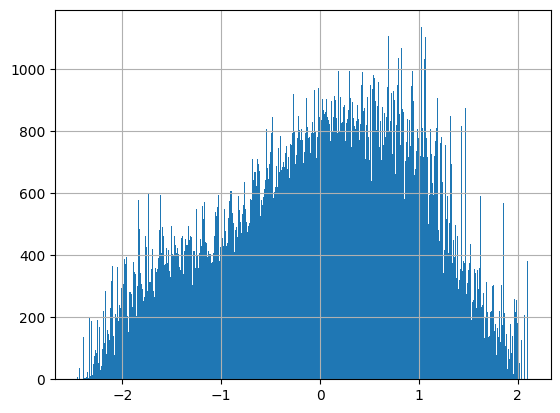

In [47]:
wealth_relevant_info.combined_score.hist(bins=500)

In [48]:
wealth_relevant_info['weighted_household_size'] = wealth_relevant_info.hh_size * wealth_relevant_info.multiplier

from statsmodels.stats.weightstats import DescrStatsW
wq = DescrStatsW(data=wealth_relevant_info.combined_score, weights=wealth_relevant_info.weighted_household_size)
quintile_cutoffs = wq.quantile(probs=np.linspace(0, 1, 6))
quintile_cutoffs

p
0.0   -2.453442
0.2   -1.142439
0.4   -0.339699
0.6    0.296405
0.8    0.887782
1.0    2.106418
dtype: float64

In [49]:
wealth_relevant_info["wealth_quintile"] = pd.cut(wealth_relevant_info.combined_score, quintile_cutoffs, labels=["lowest", "second", "middle", "fourth", "highest"], include_lowest=True)
wealth_relevant_info["wealth_quintile"]

0         second
1         fourth
2         fourth
3         middle
4         fourth
           ...  
261741    lowest
261742    lowest
261743    second
261744    second
261745    lowest
Name: wealth_quintile, Length: 261746, dtype: category
Categories (5, object): ['lowest' < 'second' < 'middle' < 'fourth' < 'highest']

In [50]:
assert wealth_relevant_info.wealth_quintile.notnull().all()

In [51]:
wealth_relevant_info.groupby("wealth_quintile", observed=True).multiplier.sum() / wealth_relevant_info.multiplier.sum()

wealth_quintile
lowest     0.194822
second     0.197195
middle     0.210537
fourth     0.198687
highest    0.198759
Name: multiplier, dtype: float64

In [52]:
for column in wealth_predictors:
    print(column)
    print(wealth_relevant_info.groupby(["wealth_quintile", column], observed=True).multiplier.sum() / wealth_relevant_info.groupby("wealth_quintile").multiplier.sum())

land_ownership
wealth_quintile  land_ownership
lowest           0.0               0.017001
                 1.0               0.982999
second           0.0               0.064876
                 1.0               0.935124
middle           0.0               0.121395
                 1.0               0.878605
fourth           0.0               0.084162
                 1.0               0.915838
highest          0.0               0.078404
                 1.0               0.921596
Name: multiplier, dtype: float64
has_dwelling
wealth_quintile  has_dwelling
lowest           0.0             0.000067
                 1.0             0.999933
second           0.0             0.000251
                 1.0             0.999749
middle           1.0             1.000000
fourth           1.0             1.000000
highest          1.0             1.000000
Name: multiplier, dtype: float64
house_ownership
wealth_quintile  house_ownership
lowest           False              0.023653
                

/tmp/ipykernel_1704758/3807259362.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(wealth_relevant_info.groupby(["wealth_quintile", column], observed=True).multiplier.sum() / wealth_relevant_info.groupby("wealth_quintile").multiplier.sum())


wealth_quintile  building_material_wall_brick
lowest           False                           0.593956
                 True                            0.406044
second           False                           0.300867
                 True                            0.699133
middle           False                           0.230983
                 True                            0.769017
fourth           False                           0.208929
                 True                            0.791071
highest          False                           0.197983
                 True                            0.802017
Name: multiplier, dtype: float64
building_material_wall_canvas
wealth_quintile  building_material_wall_canvas
lowest           False                            0.997923
                 True                             0.002077
second           False                            0.998544
                 True                             0.001456
middle           False      

wealth_quintile  building_material_roof_pucca
lowest           False                           0.979130
                 True                            0.020870
second           False                           0.986882
                 True                            0.013118
middle           False                           0.990538
                 True                            0.009462
fourth           False                           0.993529
                 True                            0.006471
highest          False                           0.998140
                 True                            0.001860
Name: multiplier, dtype: float64
building_material_roof_tiles
wealth_quintile  building_material_roof_tiles
lowest           False                           0.917670
                 True                            0.082330
second           False                           0.913832
                 True                            0.086168
middle           False            

wealth_quintile  cooking_energy_source_kerosene
lowest           False                             0.999925
                 True                              0.000075
second           False                             0.997612
                 True                              0.002388
middle           False                             0.999083
                 True                              0.000917
fourth           False                             0.999954
                 True                              0.000046
highest          False                             1.000000
Name: multiplier, dtype: float64
cooking_energy_source_liquid petroleum gas
wealth_quintile  cooking_energy_source_liquid petroleum gas
lowest           False                                         0.979162
                 True                                          0.020838
second           False                                         0.744182
                 True                                       

wealth_quintile  drinking_water_source_piped into dwelling
lowest           False                                        0.977033
                 True                                         0.022967
second           False                                        0.908805
                 True                                         0.091195
middle           False                                        0.781448
                 True                                         0.218552
fourth           False                                        0.655825
                 True                                         0.344175
highest          False                                        0.387298
                 True                                         0.612702
Name: multiplier, dtype: float64
drinking_water_source_piped to yard
wealth_quintile  drinking_water_source_piped to yard
lowest           False                                  0.950570
                 True                       

wealth_quintile  latrine_access_and_type_no latrine
lowest           False                                 0.610420
                 True                                  0.389580
second           False                                 0.826852
                 True                                  0.173148
middle           False                                 0.944949
                 True                                  0.055051
fourth           False                                 0.985256
                 True                                  0.014744
highest          False                                 0.999827
                 True                                  0.000173
Name: multiplier, dtype: float64
latrine_access_and_type_other
wealth_quintile  latrine_access_and_type_other
lowest           False                            0.998570
                 True                             0.001430
second           False                            0.998358
                 True

In [53]:
# Whoa, owning land or a house is uncorrelated?!

india_dhs = pd.read_stata(
    "/snfs1/DATA/DHS_PROG_DHS/IND/2015_2016/IND_DHS7_2015_2016_HH_IAHR74FL_Y2018M12D06.DTA", columns=["hv005", "hv270", "sh46"]
).rename(columns={"hv005": "weight", "hv270": "wealth_quintile", "sh46": "owns_house"})

In [54]:
india_dhs.groupby(["wealth_quintile", "owns_house"], observed=True).weight.sum() / india_dhs.groupby("wealth_quintile").weight.sum()

/tmp/ipykernel_1704758/2344698748.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  india_dhs.groupby(["wealth_quintile", "owns_house"], observed=True).weight.sum() / india_dhs.groupby("wealth_quintile").weight.sum()


wealth_quintile  owns_house
poorest          no            0.174830
                 yes           0.825170
poorer           no            0.179612
                 yes           0.820388
middle           no            0.213271
                 yes           0.786729
richer           no            0.248677
                 yes           0.751323
richest          no            0.191180
                 yes           0.808820
Name: weight, dtype: float64

In [55]:
# Bizarre. Even in DHS it's basically uncorrelated, although in HCES it seems to be reversed.

In [56]:
households["wealth_quintile"] = wealth_relevant_info["wealth_quintile"]

In [57]:
assert households.wealth_quintile.notnull().all()

## Household rice consumption

Item codes for 'Rice' include: 101, 102, and 061. See Section 5.1 of the above documentation for more context.

- Item code 101 signifies rice procured through PDS, using ration card.
- Item code 061 signifies rice procured through PDS, free of charge.
- Item code 102 signifies rice procured/consumed from other sources. (NOTE: Presumably this is unfortified rice.)

Units: kg/30 days.

In [58]:
consumption = pd.read_fwf(
    f'{data_dir}/hces22_lvl_05.TXT',
    header=None,
    widths = [38,1,2,3,10,8,10,8,1,15],
    names=['common_id','q_num','level','item_code','consumption_amt_home_produce',
        'consumption_value_home_produce','total_consumption_amt','total_consumption_value',
        'source','multiplier'],
)
consumption = consumption[consumption.item_code.isin([61, 101, 102])]
consumption

,common_id,q_num,level,item_code,consumption_amt_home_produce,consumption_value_home_produce,total_consumption_amt,total_consumption_value,source,multiplier
0,HCES2022655561010131113011 101202 201,F,5,102,NaN,NaN,40,1200.0,1.0,35560.0
26,HCES2022655561010131113011 101202 301,F,5,102,40,950,40,950.0,2.0,30331.0
53,HCES2022655561010131113011 101202 302,F,5,102,30,900,36,1020.0,3.0,30331.0
80,HCES2022655561010131113011 101202 303,F,5,102,NaN,NaN,25,500.0,1.0,30331.0
106,HCES2022655561010131113011 101202 304,F,5,102,20,600,20,600.0,2.0,30331.0
...,...,...,...,...,...,...,...,...,...,...
9314493,HCES20223951022828313220210228101 316,F,5,102,NaN,NaN,25.00,1300.0,1.0,73515.0
9314531,HCES20223951022828313220210228101 317,F,5,61,NaN,NaN,10.00,NaN,1.0,73515.0
9314532,HCES20223951022828313220210228101 317,F,5,102,NaN,NaN,25.00,1300.0,1.0,73515.0
9314576,HCES20223951022828313220210228101 318,F,5,61,NaN,NaN,5.00,NaN,1.0,73515.0


In [59]:
consumption["item_code"] = consumption.item_code.map({
    61: 'pds free rice',
    101: 'pds paid rice',
    102: 'other rice',
})
consumption["is_pds"] = consumption.item_code.isin(['pds free rice', 'pds paid rice'])

In [60]:
consumption["source"] = consumption.source.map({
    1: 'only purchase',
    2: 'only home-grown',
    3: 'both purchase and home-grown',
    4: 'only free collection',
    5: 'only exchange',
    6: 'only gifts',
    9: 'other',
})

In [61]:
consumption["total_consumption_amt"] = consumption.total_consumption_amt.astype(float)
consumption["consumption_amt_home_produce"] = consumption.consumption_amt_home_produce.astype(float)

In [62]:
# I assume for these high-missingness columns, null means 0
consumption.isnull().mean()

common_id                         0.000000
q_num                             0.000000
level                             0.000000
item_code                         0.000000
consumption_amt_home_produce      0.933018
consumption_value_home_produce    0.933031
total_consumption_amt             0.000000
total_consumption_value           0.261820
source                            0.000000
multiplier                        0.000000
is_pds                            0.000000
dtype: float64

In [63]:
(consumption == 0).mean()

common_id                         0.000000
q_num                             0.000000
level                             0.000000
item_code                         0.000000
consumption_amt_home_produce      0.000272
consumption_value_home_produce    0.000000
total_consumption_amt             0.000000
total_consumption_value           0.000000
source                            0.000000
multiplier                        0.000000
is_pds                            0.530847
dtype: float64

In [64]:
consumption = consumption.fillna(0)

In [65]:
consumption["pds_rice"] = np.where(
    consumption.is_pds,
    consumption.total_consumption_amt,
    0.0,
)

In [66]:
consumption["non_pds_rice_purchased"] = np.where(
    consumption.is_pds,
    0.0,
    np.where(
        consumption.source.isin(['only purchase', 'both purchase and home-grown']),
        consumption.total_consumption_amt - consumption.consumption_amt_home_produce,
        0.0,
    )
)

In [67]:
consumption["non_pds_rice_non_purchased"] = consumption.total_consumption_amt - consumption.pds_rice - consumption.non_pds_rice_purchased

In [68]:
consumption = consumption.groupby("common_id")[["pds_rice", "non_pds_rice_purchased", "non_pds_rice_non_purchased"]].sum()
consumption

,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased
common_id,,,
HCES2022310002282831212025 228111 301,0.0,3.0,0.0
HCES2022310002282831212025 228111 302,6.0,18.0,0.0
HCES2022310002282831212025 228111 303,3.0,25.0,0.0
HCES2022310002282831212025 228111 304,3.0,12.0,0.0
HCES2022310002282831212025 228111 305,1.0,3.0,0.0
...,...,...,...
HCES2022699991212130123093 221201 312,30.0,40.0,0.0
HCES2022699991212130123093 221201 313,10.0,12.0,0.0
HCES2022699991212130123093 221201 314,20.0,25.0,0.0


In [69]:
consumption["rice"] = consumption.sum(axis=1)
consumption["proportion_non_pds_purchased"] = consumption.non_pds_rice_purchased / (consumption.rice - consumption.pds_rice)
consumption

,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased
common_id,,,,,
HCES2022310002282831212025 228111 301,0.0,3.0,0.0,3.0,1.0
HCES2022310002282831212025 228111 302,6.0,18.0,0.0,24.0,1.0
HCES2022310002282831212025 228111 303,3.0,25.0,0.0,28.0,1.0
HCES2022310002282831212025 228111 304,3.0,12.0,0.0,15.0,1.0
HCES2022310002282831212025 228111 305,1.0,3.0,0.0,4.0,1.0
...,...,...,...,...,...
HCES2022699991212130123093 221201 312,30.0,40.0,0.0,70.0,1.0
HCES2022699991212130123093 221201 313,10.0,12.0,0.0,22.0,1.0
HCES2022699991212130123093 221201 314,20.0,25.0,0.0,45.0,1.0


In [70]:
len(consumption) / len(households)

0.9688209179891957

In [71]:
(households.merge(consumption, on="common_id", how="left").rice > 0).mean()

np.float64(0.9688209179891957)

In [72]:
consumption = consumption.reindex(households.common_id).fillna(0).reset_index()
consumption

,common_id,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased
0,HCES2022310002282831212025 228111 301,0.0,3.0,0.0,3.0,1.0
1,HCES2022310002282831212025 228111 302,6.0,18.0,0.0,24.0,1.0
2,HCES2022310002282831212025 228111 303,3.0,25.0,0.0,28.0,1.0
3,HCES2022310002282831212025 228111 304,3.0,12.0,0.0,15.0,1.0
4,HCES2022310002282831212025 228111 305,1.0,3.0,0.0,4.0,1.0
...,...,...,...,...,...,...
261741,HCES2022699991212130123093 221201 312,30.0,40.0,0.0,70.0,1.0
261742,HCES2022699991212130123093 221201 313,10.0,12.0,0.0,22.0,1.0
261743,HCES2022699991212130123093 221201 314,20.0,25.0,0.0,45.0,1.0
261744,HCES2022699991212130123093 221201 315,35.0,35.0,0.0,70.0,1.0


In [73]:
(households.merge(consumption, on="common_id", how="left").rice > 0).mean()

np.float64(0.9688209179891957)

## Individual rice consumption

We distribute the rice to the individuals according to the number of meals they have eaten at home.
We assume that children eating school lunches are getting fortified rice, as the scale-up has also
happened through that program.
Otherwise, we assume that meals eaten away from the home use rice and fortified rice at the same rate
as meals at home.

In [74]:
household_members = pd.read_fwf(
    '/snfs1/DATA/Incoming Data/IND/HOUSEHOLD_CONSUMPTION_EXPENDITURE_SURVEY_HCES/2022_2023/hces22_lvl_02.TXT',
    header=None,
    widths=[38,1,2,2,1,1,3,1,2,2,1,2,1,2,2,2,2,2,1,1,15],
    names=[
        "common_id",
        "questionnaire_no",
        "level",
        "person_serial_no",
        "relation_to_head_code",
        "gender",
        "age_years",
        "marital_status_code",
        "highest_education_level_code",
        "total_years_education",
        "internet_use_last_30_days",
        "days_away_from_home_last_30_days",
        "usual_daily_meals",
        "meals_from_school_balwadi_last_30_days",
        "meals_from_employer_last_30_days",
        "meals_others_last_30_days",
        "meals_paid_last_30_days",
        "meals_at_home_last_30_days",
        "member_status_on_revisit",
        "fdq_orig_number",
        "multiplier",
    ],
)
household_members = household_members[
    ["common_id", "gender", "age_years", "multiplier"] +
    [c for c in household_members.columns if 'meals' in c]
]
household_members

,common_id,gender,age_years,multiplier,usual_daily_meals,meals_from_school_balwadi_last_30_days,meals_from_employer_last_30_days,meals_others_last_30_days,meals_paid_last_30_days,meals_at_home_last_30_days
0,HCES2022655561010131113011 101202 201,1,48,35560.0,2.0,0.0,0.0,0.0,0.0,58.0
1,HCES2022655561010131113011 101202 201,2,46,35560.0,2.0,NaN,NaN,NaN,NaN,60.0
2,HCES2022655561010131113011 101202 201,1,24,35560.0,2.0,NaN,NaN,NaN,NaN,58.0
3,HCES2022655561010131113011 101202 201,1,18,35560.0,2.0,NaN,NaN,NaN,NaN,56.0
4,HCES2022655561010131113011 101202 201,2,21,35560.0,2.0,NaN,NaN,NaN,NaN,54.0
...,...,...,...,...,...,...,...,...,...,...
1127034,HCES20223492023737102120110201201 313,1,40,938.0,2.0,0.0,0.0,0.0,5.0,55.0
1127035,HCES20223492023737102120110201201 313,2,38,938.0,2.0,0.0,0.0,0.0,0.0,60.0
1127036,HCES20223492023737102120110201201 313,1,12,938.0,2.0,0.0,0.0,0.0,0.0,60.0
1127037,HCES20223492023737102120110201201 313,2,7,938.0,2.0,0.0,0.0,0.0,0.0,60.0


In [75]:
# My interpretation: null basically is equivalent to 0 for these high-missingness columns...
household_members.filter(like='meals').isnull().mean()

usual_daily_meals                         0.002661
meals_from_school_balwadi_last_30_days    0.650829
meals_from_employer_last_30_days          0.689258
meals_others_last_30_days                 0.617970
meals_paid_last_30_days                   0.640668
meals_at_home_last_30_days                0.007464
dtype: float64

In [76]:
# ... even though there are actual zeros!
(household_members.filter(like='meals') == 0).mean()

usual_daily_meals                         0.007479
meals_from_school_balwadi_last_30_days    0.288050
meals_from_employer_last_30_days          0.304265
meals_others_last_30_days                 0.268969
meals_paid_last_30_days                   0.285900
meals_at_home_last_30_days                0.007285
dtype: float64

In [77]:
for col in ["meals_from_school_balwadi_last_30_days", "meals_from_employer_last_30_days", "meals_others_last_30_days", "meals_paid_last_30_days"]:
    household_members[col] = household_members[col].fillna(0)

In [78]:
household_members.isnull().mean()

common_id                                 0.000000
gender                                    0.000000
age_years                                 0.000000
multiplier                                0.000000
usual_daily_meals                         0.002661
meals_from_school_balwadi_last_30_days    0.000000
meals_from_employer_last_30_days          0.000000
meals_others_last_30_days                 0.000000
meals_paid_last_30_days                   0.000000
meals_at_home_last_30_days                0.007464
dtype: float64

In [79]:
# Complete-case analysis
household_members = household_members.dropna(how="any").copy()
household_members

,common_id,gender,age_years,multiplier,usual_daily_meals,meals_from_school_balwadi_last_30_days,meals_from_employer_last_30_days,meals_others_last_30_days,meals_paid_last_30_days,meals_at_home_last_30_days
0,HCES2022655561010131113011 101202 201,1,48,35560.0,2.0,0.0,0.0,0.0,0.0,58.0
1,HCES2022655561010131113011 101202 201,2,46,35560.0,2.0,0.0,0.0,0.0,0.0,60.0
2,HCES2022655561010131113011 101202 201,1,24,35560.0,2.0,0.0,0.0,0.0,0.0,58.0
3,HCES2022655561010131113011 101202 201,1,18,35560.0,2.0,0.0,0.0,0.0,0.0,56.0
4,HCES2022655561010131113011 101202 201,2,21,35560.0,2.0,0.0,0.0,0.0,0.0,54.0
...,...,...,...,...,...,...,...,...,...,...
1127034,HCES20223492023737102120110201201 313,1,40,938.0,2.0,0.0,0.0,0.0,5.0,55.0
1127035,HCES20223492023737102120110201201 313,2,38,938.0,2.0,0.0,0.0,0.0,0.0,60.0
1127036,HCES20223492023737102120110201201 313,1,12,938.0,2.0,0.0,0.0,0.0,0.0,60.0
1127037,HCES20223492023737102120110201201 313,2,7,938.0,2.0,0.0,0.0,0.0,0.0,60.0


In [80]:
household_members["gender"] = household_members.gender.map({
    1: 'male',
    2: 'female',
    3: 'transgender',
})

In [81]:
household_members = household_members.merge(households[["common_id", "wealth_quintile"]], on="common_id", validate="m:1", how="left")

In [82]:
assert household_members.wealth_quintile.notnull().all()

In [83]:
household_members["meals"] = (
    household_members.meals_at_home_last_30_days.fillna(0) +
    household_members.meals_from_employer_last_30_days.fillna(0) +
    household_members.meals_from_school_balwadi_last_30_days.fillna(0) +
    household_members.meals_from_employer_last_30_days.fillna(0) +
    household_members.meals_paid_last_30_days.fillna(0) +
    household_members.meals_others_last_30_days.fillna(0)
)

<Axes: xlabel='usual_daily_meals', ylabel='meals'>

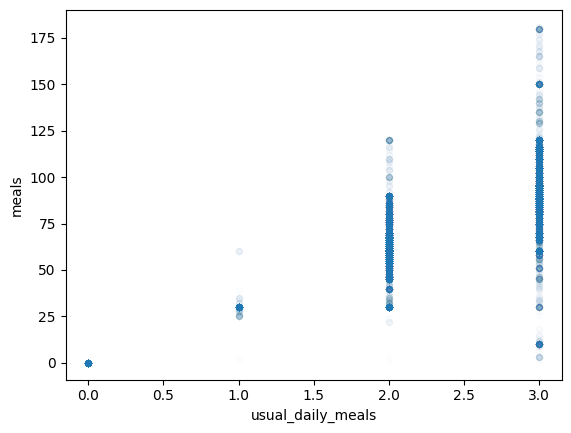

In [84]:
household_members.plot(kind='scatter', x='usual_daily_meals', y='meals', alpha=0.01)

In [85]:
household_meals = household_members.groupby("common_id").meals_at_home_last_30_days.sum()
household_meals

common_id
HCES2022310002282831212025 228111  301     30.0
HCES2022310002282831212025 228111  302    408.0
HCES2022310002282831212025 228111  303    450.0
HCES2022310002282831212025 228111  304    180.0
HCES2022310002282831212025 228111  305     30.0
                                          ...  
HCES2022699991212130123093 221201  312    671.0
HCES2022699991212130123093 221201  313    180.0
HCES2022699991212130123093 221201  314    360.0
HCES2022699991212130123093 221201  315    333.0
HCES2022699991212130123093 221201  316    480.0
Name: meals_at_home_last_30_days, Length: 259624, dtype: float64

In [86]:
consumption = consumption.merge(household_meals, on="common_id", validate="1:1", how="left")
consumption

,common_id,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased,meals_at_home_last_30_days
0,HCES2022310002282831212025 228111 301,0.0,3.0,0.0,3.0,1.0,30.0
1,HCES2022310002282831212025 228111 302,6.0,18.0,0.0,24.0,1.0,408.0
2,HCES2022310002282831212025 228111 303,3.0,25.0,0.0,28.0,1.0,450.0
3,HCES2022310002282831212025 228111 304,3.0,12.0,0.0,15.0,1.0,180.0
4,HCES2022310002282831212025 228111 305,1.0,3.0,0.0,4.0,1.0,30.0
...,...,...,...,...,...,...,...
261741,HCES2022699991212130123093 221201 312,30.0,40.0,0.0,70.0,1.0,671.0
261742,HCES2022699991212130123093 221201 313,10.0,12.0,0.0,22.0,1.0,180.0
261743,HCES2022699991212130123093 221201 314,20.0,25.0,0.0,45.0,1.0,360.0
261744,HCES2022699991212130123093 221201 315,35.0,35.0,0.0,70.0,1.0,333.0


In [87]:
consumption.isnull().mean()

common_id                       0.000000
pds_rice                        0.000000
non_pds_rice_purchased          0.000000
non_pds_rice_non_purchased      0.000000
rice                            0.000000
proportion_non_pds_purchased    0.000000
meals_at_home_last_30_days      0.008107
dtype: float64

In [88]:
consumption = consumption.dropna(how="any").copy()
consumption

,common_id,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased,meals_at_home_last_30_days
0,HCES2022310002282831212025 228111 301,0.0,3.0,0.0,3.0,1.0,30.0
1,HCES2022310002282831212025 228111 302,6.0,18.0,0.0,24.0,1.0,408.0
2,HCES2022310002282831212025 228111 303,3.0,25.0,0.0,28.0,1.0,450.0
3,HCES2022310002282831212025 228111 304,3.0,12.0,0.0,15.0,1.0,180.0
4,HCES2022310002282831212025 228111 305,1.0,3.0,0.0,4.0,1.0,30.0
...,...,...,...,...,...,...,...
261741,HCES2022699991212130123093 221201 312,30.0,40.0,0.0,70.0,1.0,671.0
261742,HCES2022699991212130123093 221201 313,10.0,12.0,0.0,22.0,1.0,180.0
261743,HCES2022699991212130123093 221201 314,20.0,25.0,0.0,45.0,1.0,360.0
261744,HCES2022699991212130123093 221201 315,35.0,35.0,0.0,70.0,1.0,333.0


In [89]:
consumption["rice_per_meal_kg"] = np.where(
    consumption.rice == 0,
    0.0,
    consumption.rice / consumption.meals_at_home_last_30_days
)

In [90]:
# In a small number of cases, rice consumption is reported despite very few or no meals at home
impossible_rice_consumption = (consumption.rice > 0) & (consumption.meals_at_home_last_30_days == 0)
consumption[impossible_rice_consumption]

,common_id,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased,meals_at_home_last_30_days,rice_per_meal_kg
5845,HCES2022313712252510212018 124241 314,0.0,6.0,0.0,6.0,1.0,0.0,inf
15348,HCES2022319332272730332022 127111 309,2.0,3.0,0.0,5.0,1.0,0.0,inf
22433,HCES2022323692202021012028 220151 306,0.0,6.0,0.0,6.0,1.0,0.0,inf
31974,HCES2022329292222220422028 222121 308,0.0,0.0,8.0,8.0,0.0,0.0,inf
31977,HCES2022329292222220422028 222121 311,0.0,0.0,12.0,12.0,0.0,0.0,inf
31980,HCES2022329292222220422028 222121 314,0.0,0.0,12.0,12.0,0.0,0.0,inf
31983,HCES2022329292222220422028 222121 317,0.0,0.0,12.0,12.0,0.0,0.0,inf
48967,HCES2022339822171710622012 217101 313,0.0,5.0,0.0,5.0,1.0,0.0,inf
49455,HCES2022341092363612342053 236102 314,0.0,10.0,0.0,10.0,1.0,0.0,inf
50369,HCES2022341602363612342015 236101 314,0.0,8.0,0.0,8.0,1.0,0.0,inf


In [91]:
# This must be wrong somehow, so we clip it
consumption["rice_per_meal_kg"] = consumption["rice_per_meal_kg"].clip(upper=np.percentile(consumption.rice_per_meal_kg, 95))

<Axes: >

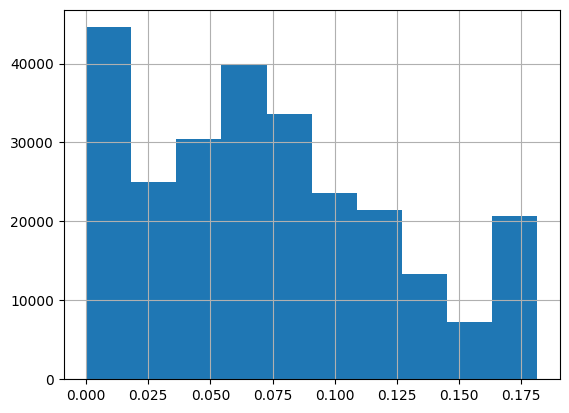

In [92]:
consumption[consumption.rice_per_meal_kg.notnull()].sort_values('rice_per_meal_kg')
consumption.rice_per_meal_kg.hist()

<Axes: >

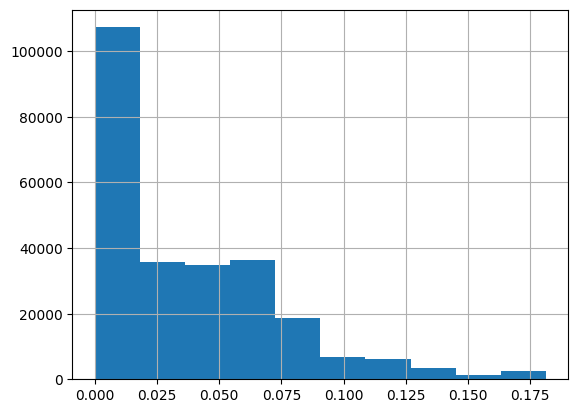

In [93]:
consumption["pds_rice_per_meal_kg"] = consumption.rice_per_meal_kg * (consumption.pds_rice / consumption.rice)
consumption.pds_rice_per_meal_kg.hist()

In [94]:
household_members = household_members.merge(
    consumption.reset_index()[["common_id", "rice_per_meal_kg", "pds_rice_per_meal_kg", "proportion_non_pds_purchased"]],
    on="common_id",
    how="left",
    validate="m:1",
)
household_members

,common_id,gender,age_years,multiplier,usual_daily_meals,meals_from_school_balwadi_last_30_days,meals_from_employer_last_30_days,meals_others_last_30_days,meals_paid_last_30_days,meals_at_home_last_30_days,wealth_quintile,meals,rice_per_meal_kg,pds_rice_per_meal_kg,proportion_non_pds_purchased
0,HCES2022655561010131113011 101202 201,male,48,35560.0,2.0,0.0,0.0,0.0,0.0,58.0,highest,58.0,0.139860,0.000000,1.0
1,HCES2022655561010131113011 101202 201,female,46,35560.0,2.0,0.0,0.0,0.0,0.0,60.0,highest,60.0,0.139860,0.000000,1.0
2,HCES2022655561010131113011 101202 201,male,24,35560.0,2.0,0.0,0.0,0.0,0.0,58.0,highest,58.0,0.139860,0.000000,1.0
3,HCES2022655561010131113011 101202 201,male,18,35560.0,2.0,0.0,0.0,0.0,0.0,56.0,highest,56.0,0.139860,0.000000,1.0
4,HCES2022655561010131113011 101202 201,female,21,35560.0,2.0,0.0,0.0,0.0,0.0,54.0,highest,54.0,0.139860,0.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118622,HCES20223492023737102120110201201 313,male,40,938.0,2.0,0.0,0.0,0.0,5.0,55.0,fourth,60.0,0.101695,0.067797,1.0
1118623,HCES20223492023737102120110201201 313,female,38,938.0,2.0,0.0,0.0,0.0,0.0,60.0,fourth,60.0,0.101695,0.067797,1.0
1118624,HCES20223492023737102120110201201 313,male,12,938.0,2.0,0.0,0.0,0.0,0.0,60.0,fourth,60.0,0.101695,0.067797,1.0
1118625,HCES20223492023737102120110201201 313,female,7,938.0,2.0,0.0,0.0,0.0,0.0,60.0,fourth,60.0,0.101695,0.067797,1.0


In [95]:
household_members.isnull().mean()

common_id                                 0.000000
gender                                    0.000000
age_years                                 0.000000
multiplier                                0.000000
usual_daily_meals                         0.000000
meals_from_school_balwadi_last_30_days    0.000000
meals_from_employer_last_30_days          0.000000
meals_others_last_30_days                 0.000000
meals_paid_last_30_days                   0.000000
meals_at_home_last_30_days                0.000000
wealth_quintile                           0.000000
meals                                     0.000000
rice_per_meal_kg                          0.000000
pds_rice_per_meal_kg                      0.017985
proportion_non_pds_purchased              0.000000
dtype: float64

In [96]:
household_members["government_meals_away_from_home"] = household_members.meals_from_school_balwadi_last_30_days
household_members["non_government_meals_away_from_home"] = household_members.meals - household_members.meals_at_home_last_30_days - household_members.government_meals_away_from_home
household_members["rice"] = (
    household_members.meals * household_members.rice_per_meal_kg
)
household_members["government_rice"] = (
    household_members.meals_at_home_last_30_days * household_members.pds_rice_per_meal_kg +
    (household_members.government_meals_away_from_home * household_members.rice_per_meal_kg) +
    (household_members.non_government_meals_away_from_home * household_members.pds_rice_per_meal_kg) # Assume same as at-home meals
)
household_members["proportion_government"] = household_members.government_rice / household_members.rice
household_members["proportion_fortifiable"] = (
    # It's assumed that all non-government rice you consume is fortifiable if it was purchased; we use your household's rate of
    # purchasing vs growing for non-PDS rice for this.
    # All government rice is fortifiable.
    (household_members.government_rice + (household_members.proportion_non_pds_purchased * (household_members.rice - household_members.government_rice))) /
    household_members.rice
)

In [97]:
household_members.isnull().mean()

common_id                                 0.000000
gender                                    0.000000
age_years                                 0.000000
multiplier                                0.000000
usual_daily_meals                         0.000000
meals_from_school_balwadi_last_30_days    0.000000
meals_from_employer_last_30_days          0.000000
meals_others_last_30_days                 0.000000
meals_paid_last_30_days                   0.000000
meals_at_home_last_30_days                0.000000
wealth_quintile                           0.000000
meals                                     0.000000
rice_per_meal_kg                          0.000000
pds_rice_per_meal_kg                      0.017985
proportion_non_pds_purchased              0.000000
government_meals_away_from_home           0.000000
non_government_meals_away_from_home       0.000000
rice                                      0.000000
government_rice                           0.017985
proportion_government          

In [98]:
# Convert kg/30 days to g/day
household_members["rice_g_per_day"] = household_members.rice / 30 * 1_000

### WRA (proxy for pregnant people)

In [99]:
wra_df = household_members[(household_members.gender == 'female') & (household_members.age_years >= 10) & (household_members.age_years < 55)]
wra_df

,common_id,gender,age_years,multiplier,usual_daily_meals,meals_from_school_balwadi_last_30_days,meals_from_employer_last_30_days,meals_others_last_30_days,meals_paid_last_30_days,meals_at_home_last_30_days,...,rice_per_meal_kg,pds_rice_per_meal_kg,proportion_non_pds_purchased,government_meals_away_from_home,non_government_meals_away_from_home,rice,government_rice,proportion_government,proportion_fortifiable,rice_g_per_day
1,HCES2022655561010131113011 101202 201,female,46,35560.0,2.0,0.0,0.0,0.0,0.0,60.0,...,0.139860,0.000000,1.000000,0.0,0.0,8.391608,0.000000,0.000000,1.000000,279.720280
4,HCES2022655561010131113011 101202 201,female,21,35560.0,2.0,0.0,0.0,0.0,0.0,54.0,...,0.139860,0.000000,1.000000,0.0,0.0,7.552448,0.000000,0.000000,1.000000,251.748252
6,HCES2022655561010131113011 101202 301,female,45,30331.0,2.0,0.0,0.0,0.0,0.0,60.0,...,0.112360,0.000000,0.000000,0.0,0.0,6.741573,0.000000,0.000000,0.000000,224.719101
9,HCES2022655561010131113011 101202 301,female,19,30331.0,2.0,0.0,0.0,0.0,0.0,60.0,...,0.112360,0.000000,0.000000,0.0,0.0,6.741573,0.000000,0.000000,0.000000,224.719101
13,HCES2022655561010131113011 101202 302,female,33,30331.0,2.0,0.0,0.0,0.0,0.0,58.0,...,0.076433,0.000000,0.166667,0.0,0.0,4.433121,0.000000,0.000000,0.166667,147.770701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118601,HCES20223492023737102120110201201 308,female,28,938.0,2.0,0.0,0.0,0.0,2.0,58.0,...,0.102740,0.068493,1.000000,0.0,2.0,6.164384,4.109589,0.666667,1.000000,205.479452
1118610,HCES20223492023737102120110201201 310,female,28,938.0,2.0,0.0,0.0,0.0,0.0,60.0,...,0.117188,0.078125,1.000000,0.0,0.0,7.031250,4.687500,0.666667,1.000000,234.375000
1118619,HCES20223492023737102120110201201 312,female,45,938.0,2.0,0.0,0.0,0.0,3.0,57.0,...,0.108696,0.065217,1.000000,0.0,3.0,6.521739,3.913043,0.600000,1.000000,217.391304
1118621,HCES20223492023737102120110201201 312,female,12,938.0,2.0,0.0,0.0,0.0,0.0,60.0,...,0.108696,0.065217,1.000000,0.0,0.0,6.521739,3.913043,0.600000,1.000000,217.391304


In [100]:
# https://stackoverflow.com/a/2415343/ with some tweaks
def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    is_nan = np.isnan(values)
    values = values[~is_nan]
    weights = weights[~is_nan]
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values - average) ** 2, weights=weights)
    return pd.Series(
        {
            "mean": average,
            "sd": np.sqrt(variance),
            # https://ngreifer.github.io/WeightIt/reference/ESS.html
            "effective_sample_size": (weights.sum() ** 2) / (weights**2).sum(),
        }
    )

In [101]:
pregnancy_sim_data_dir = '../../0200_pregnancy_sim/src/vivarium_gates_lsff_by_wealth_quintile/data/raw_data'

In [102]:
def save_data(series, name):
    (
        series.rename("value").reset_index()
            .assign(vehicle_name='rice')
            .to_csv(f'{pregnancy_sim_data_dir}/{name}/india.csv', index=False)
    )

In [103]:
any_consumption = (
    wra_df.groupby(["wealth_quintile"])
    .apply(lambda df: weighted_avg_and_std(df.rice_g_per_day > 0, weights=df.multiplier))
    .sort_index()
)
any_consumption

/tmp/ipykernel_1704758/2507177430.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wra_df.groupby(["wealth_quintile"])
/tmp/ipykernel_1704758/2507177430.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: weighted_avg_and_std(df.rice_g_per_day > 0, weights=df.multiplier))


,mean,sd,effective_sample_size
wealth_quintile,,,
lowest,0.990037,0.099318,15280.687083
second,0.971339,0.166852,48417.449061
middle,0.966654,0.179539,54814.317970
fourth,0.985569,0.119260,54080.735573
highest,0.988214,0.107922,48570.123815


In [104]:
save_data(any_consumption["mean"], "vehicle_consumption/any")

In [105]:
consumption_amount = (
    wra_df.groupby(["wealth_quintile"])
    .apply(lambda df: weighted_avg_and_std(df.rice_g_per_day, weights=df.multiplier))
    .sort_index()
)
consumption_amount

/tmp/ipykernel_1704758/1175765591.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wra_df.groupby(["wealth_quintile"])
/tmp/ipykernel_1704758/1175765591.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: weighted_avg_and_std(df.rice_g_per_day, weights=df.multiplier))


,mean,sd,effective_sample_size
wealth_quintile,,,
lowest,213.570675,122.057888,15280.687083
second,175.027768,120.778604,48417.449061
middle,163.699804,117.685540,54814.317970
fourth,163.363078,116.248754,54080.735573
highest,127.874174,104.866010,48570.123815


In [106]:
save_data(consumption_amount["mean"], "vehicle_consumption/amount/mean")
save_data(consumption_amount["sd"], "vehicle_consumption/amount/sd")

In [107]:
# NOTE: Government rice fortification scale-up is still in progress.
# According to this dashboard (https://impds.nic.in/sale/stateUnautmated?month=1&year=2024) it is
# around 70% in 2024. We say that it can't get above 80% due to compliance issues.
# We apply maximum individual heterogeneity, meaning that the people who are missed
# due to compliance are *completely* missed.
GOVERNMENT_BASELINE_COVERAGE = 0.8

In [108]:
any_fortification = (
    wra_df.groupby(["wealth_quintile"])
    .apply(lambda df: GOVERNMENT_BASELINE_COVERAGE * weighted_avg_and_std(df.proportion_government > 0, weights=df.multiplier))
    .sort_index()
)
any_fortification

/tmp/ipykernel_1704758/3646790937.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wra_df.groupby(["wealth_quintile"])
/tmp/ipykernel_1704758/3646790937.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: GOVERNMENT_BASELINE_COVERAGE * weighted_avg_and_std(df.proportion_government > 0, weights=df.multiplier))


,mean,sd,effective_sample_size
wealth_quintile,,,
lowest,0.678272,0.287340,12224.549666
second,0.637306,0.322003,38733.959249
middle,0.577356,0.358531,43851.454376
fourth,0.533879,0.376930,43264.588458
highest,0.326044,0.393104,38856.099052


In [109]:
save_data(any_fortification["mean"], "baseline_fortification/any_coverage")

In [110]:
full_fortification = (
    wra_df.groupby(["wealth_quintile"])
    .apply(lambda df: GOVERNMENT_BASELINE_COVERAGE * weighted_avg_and_std(df.proportion_government == 1, weights=df.multiplier))
    .sort_index()
)
full_fortification

/tmp/ipykernel_1704758/3978962865.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wra_df.groupby(["wealth_quintile"])
/tmp/ipykernel_1704758/3978962865.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: GOVERNMENT_BASELINE_COVERAGE * weighted_avg_and_std(df.proportion_government == 1, weights=df.multiplier))


,mean,sd,effective_sample_size
wealth_quintile,,,
lowest,0.185423,0.337575,12224.549666
second,0.211519,0.352810,38733.959249
middle,0.189856,0.340352,43851.454376
fourth,0.152393,0.314151,43264.588458
highest,0.076918,0.235835,38856.099052


In [111]:
save_data(full_fortification["mean"], "baseline_fortification/full_coverage")

In [112]:
partial_fortification_amount = (
    wra_df[(wra_df.proportion_government > 0) & (wra_df.proportion_government < 1)].groupby(["wealth_quintile"])
    .apply(lambda df: weighted_avg_and_std(df.proportion_government, weights=df.multiplier))
    .sort_index()
)
partial_fortification_amount

/tmp/ipykernel_1704758/1161050072.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wra_df[(wra_df.proportion_government > 0) & (wra_df.proportion_government < 1)].groupby(["wealth_quintile"])
/tmp/ipykernel_1704758/1161050072.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: weighted_avg_and_std(df.proportion_government, weights=df.multiplier))


,mean,sd,effective_sample_size
wealth_quintile,,,
lowest,0.544184,0.189493,9777.175823
second,0.562533,0.192094,23032.794698
middle,0.556596,0.201018,26564.908800
fourth,0.531211,0.205882,25586.793288
highest,0.486656,0.210789,14719.184473


In [113]:
save_data(partial_fortification_amount["mean"], "baseline_fortification/partial_coverage_amount/mean")
save_data(partial_fortification_amount["sd"], "baseline_fortification/partial_coverage_amount/sd")

In [114]:
proportion_government = (
    wra_df.groupby(["wealth_quintile"])
    .apply(lambda df: weighted_avg_and_std(df.proportion_government, weights=df.multiplier))
    .sort_index()
)
proportion_government

/tmp/ipykernel_1704758/3904366692.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wra_df.groupby(["wealth_quintile"])
/tmp/ipykernel_1704758/3904366692.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: weighted_avg_and_std(df.proportion_government, weights=df.multiplier))


,mean,sd,effective_sample_size
wealth_quintile,,,
lowest,0.574839,0.336706,15018.031403
second,0.582899,0.360116,47314.921347
middle,0.527186,0.383583,54549.848034
fourth,0.452597,0.385726,53255.308934
highest,0.251798,0.352324,48056.472298


In [115]:
# Save locally for further scaling in the extraction notebook
proportion_government["mean"].rename("value").to_csv('india_proportion_government.csv')

In [116]:
fortifiability_disparities = (
    wra_df.groupby(["wealth_quintile"])
    .apply(lambda df: weighted_avg_and_std(df.proportion_fortifiable, weights=df.multiplier))
    .sort_index()
)
fortifiability_disparities

/tmp/ipykernel_1704758/3717732404.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wra_df.groupby(["wealth_quintile"])
/tmp/ipykernel_1704758/3717732404.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: weighted_avg_and_std(df.proportion_fortifiable, weights=df.multiplier))


,mean,sd,effective_sample_size
wealth_quintile,,,
lowest,0.895527,0.228417,15018.031403
second,0.911167,0.221014,47314.921347
middle,0.935564,0.202050,54549.848034
fourth,0.945074,0.197619,53255.308934
highest,0.966887,0.167534,48056.472298


In [117]:
# Save locally for further scaling in the extraction notebook
fortifiability_disparities["mean"].rename("value").to_csv('india_fortifiability_disparities.csv')